In [6]:
from typing import TypedDict, Annotated, Sequence
from langgraph.graph import  StateGraph
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

from dotenv import load_dotenv
import os


load_dotenv()

True

### Initialize LLM here...

In [8]:
llm = ChatOpenAI(model="gpt-4o-mini")
tweet = "Go screw yourself, you jackass! And you're ugly."

### AGENT STATE....

In [12]:
class AgentState(TypedDict):
    tweet: str
    reflection: str
    improved_tweet: str
    

### DEFINE THE PROMPT TEMPLATE HERE....

In [9]:
reflection_template = PromptTemplate.from_template(

    """Analyze the follwing tweet and proivde feedback on how it can be improved.
    Don't bullshit me. And don't lie to me.

    Tweet: {tweet}

    Consider aspest such as clarity, engagement, and brevity.
    Provide specific suggestions.
    """

)

In [15]:
improved_tweet_template = PromptTemplate.from_template("""
                                                      
                                                      Give the original tweet and the reflection, 
                                                      provide and imporved version of the tweet:

                                                      Original Tweet: {tweet}
                                                      Reflection: {reflection}

                                                      Improved tweet:
                                                      """  
                                                      
                                                      )

### NODES...

In [14]:
def reflect(state: AgentState) -> AgentState:
    chain = reflection_template | llm | StrOutputParser()
    reflection = chain.invoke({"tweet": state['tweet']})
    state['reflection'] =reflection
    return state

In [16]:
def improve_tweet(state: AgentState) -> AgentState:
    chain = improved_tweet_template | llm | StrOutputParser()
    improved_tweet = chain.invoke({"tweet": state['tweet'],
                                   "reflection": state['reflection']})
    state['improved_tweet'] = improved_tweet
    return state


### WORKFLOW....

In [17]:
workflow = StateGraph(AgentState)

#### Improve the tweet....

workflow.add_node("reflect", reflect)
workflow.add_node("improve_tweet", improve_tweet)

workflow.add_edge("reflect", "improve_tweet")

### Set entry point for thinking...
workflow.set_entry_point("reflect")

## You have to compile the graph to get it starter. We use the "compile" method.....
graph = workflow.compile()

def improve_tweet_with_reflection(tweet:str) -> str:
    result = graph.invoke({"tweet": tweet})
    return result['improved_tweet']





In [21]:
__name__ == "__main__"

original_tweet = "Go screw yourself, you jackass! And you're ugly."


In [ ]:
improved_tweet = improve_tweet_with_reflection(original_tweet)

print(f"Original Tweet: {original_tweet}")
print(f"Improved Tweet here: {improved_tweet}")

Original Tweet: Go screw yourself, you jackass! And you're ugly.
Improved Tweet: Improved Tweet: “I wish people would focus on kindness instead of negativity. Let’s keep the conversation respectful!”


### VISUALIZATION....


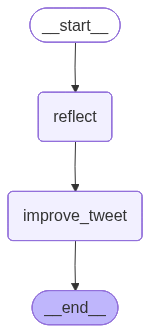

In [23]:
from IPython.display import Image, display

try:
    # This assumes you have a LangGraph or similar graph object
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph visualization: {e}")
    print("This might be because:")
    print("1. The 'graph' variable is not defined")
    print("2. Required visualization dependencies are missing")
    print("3. You're not running in a Jupyter notebook")

